In [1]:
import ast
import copy
import re
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm
from PIL import Image
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, classification_report,
                              f1_score, accuracy_score, recall_score)
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")


In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
PREPROC_DIR = Path("/home/compbio10/disc_novartis/ODIR_5K/preprocessed_images")
TRAINING_DIR = Path("/home/compbio10/disc_novartis/ODIR_5K/ODIR-5K/Training Images")
TESTING_DIR = Path("/home/compbio10/disc_novartis/ODIR_5K/ODIR-5K/Testing Images")

In [4]:
BACKBONE = "resnet50"    
BATCH_SIZE = 128
FREEZE_EPOCHS = 3                
TOTAL_EPOCHS = 25                
HEAD_LR = 1e-3
FT_LR = 1e-4                     
HEAD_LR_MULT_FT = 3              
WEIGHT_DECAY = 3e-4              
HEAD_DROPOUT = 0.4               
APPLY_CLAHE = True                


N_UNFREEZE_GROUPS = 4             
EPOCHS_PER_UNFREEZE_GROUP = 3      
UNFREEZE_LR_DECAY = 0.5           
FINAL_STAGE_LR = 5e-5             
                                   


EARLY_STOP_PATIENCE = 6           
EARLY_STOP_MIN_DELTA = 1e-4
PLATEAU_FACTOR = 0.5              
PLATEAU_PATIENCE = 2


N_FOLDS = 5                      
CV_RANDOM_STATE = 42

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 300
IMG_MEAN = (0.485, 0.456, 0.406)
IMG_STD = (0.229, 0.224, 0.225)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [6]:
seen = {}
for d in [PREPROC_DIR, TRAINING_DIR, TESTING_DIR]:
    if not d.exists():
        print(f"[warn] directory does not exist, skipping: {d}")
        continue
    for p in sorted(d.rglob("*")):
        if not p.is_file() or p.suffix.lower() not in ".jpg":
            continue
        if p.name not in seen:
            seen[p.name] = str(p)
filename_to_path = seen
print(f"{len(filename_to_path)} unique image files found on disk")

8000 unique image files found on disk


In [7]:
full_df = pd.read_csv("/home/compbio10/disc_novartis/ODIR_5K/full_df.csv")
full_df["target_parsed"] = full_df["target"].apply(ast.literal_eval)
full_df["normal_precise"] = full_df["target_parsed"].apply(lambda t: int(t[0]))  
tier1 = full_df[["filename", "normal_precise"]].drop_duplicates(subset="filename")

In [8]:
patient_meta = pd.read_excel("/home/compbio10/disc_novartis/ODIR_5K/ODIR-5K/data.xlsx")
label_cols = ["N", "D", "G", "C", "A", "H", "M", "O"]
left = patient_meta[["Left-Fundus"] + label_cols].rename(columns={"Left-Fundus": "filename"})
right = patient_meta[["Right-Fundus"] + label_cols].rename(columns={"Right-Fundus": "filename"})
patient_melted = pd.concat([left, right], ignore_index=True).drop_duplicates(subset="filename")
patient_melted["normal_patient"] = patient_melted["N"].astype(int)
tier2 = patient_melted[["filename", "normal_patient"]]

In [9]:
meta = pd.DataFrame({"filename": list(filename_to_path.keys())})
meta = meta.merge(tier1, on="filename", how="left").merge(tier2, on="filename", how="left")

meta["normal"] = meta["normal_precise"]
fallback_mask = meta["normal"].isna() & meta["normal_patient"].notna()
meta.loc[fallback_mask, "normal"] = meta.loc[fallback_mask, "normal_patient"]

labeled_meta = meta[meta["normal"].notna()].copy()
labeled_meta["label"] = 1 - labeled_meta["normal"].astype(int)
labeled_meta["path"] = labeled_meta["filename"].map(filename_to_path)

unlabeled_meta = meta[meta["normal"].isna()].copy()
unlabeled_meta["path"] = unlabeled_meta["filename"].map(filename_to_path)

print(f"Labeled: {len(labeled_meta)}   Unlabeled (e.g. Testing Images): {len(unlabeled_meta)}")
print(f"Class counts -> Normal (0): {(labeled_meta['label']==0).sum()}   Disease (1): {(labeled_meta['label']==1).sum()}")

Labeled: 7000   Unlabeled (e.g. Testing Images): 1000
Class counts -> Normal (0): 3052   Disease (1): 3948


In [10]:
def extract_patient_id(filename):
    m = re.match(r"(\d+)_", filename)
    return m.group(1) if m else filename  
labeled_meta["patient_id"] = labeled_meta["filename"].apply(extract_patient_id)
labeled_meta = labeled_meta.reset_index(drop=True)

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=CV_RANDOM_STATE)

fold_splits = []  
for fold_idx, (train_idx, val_idx) in enumerate(
    sgkf.split(labeled_meta, labeled_meta["label"], groups=labeled_meta["patient_id"])
):
    train_ids = set(labeled_meta.iloc[train_idx]["patient_id"])
    val_ids = set(labeled_meta.iloc[val_idx]["patient_id"])
    overlap = train_ids & val_ids
    assert len(overlap) == 0, f"Patient leakage detected in fold {fold_idx}: {overlap}"
    fold_splits.append((fold_idx, train_idx, val_idx))

print(f"Leakage check passed for all {N_FOLDS} folds — no shared patient IDs between train/val within any fold.\n")
for fold_idx, train_idx, val_idx in fold_splits:
    tr = labeled_meta.iloc[train_idx]
    va = labeled_meta.iloc[val_idx]
    print(f"Fold {fold_idx}: train={len(tr)} (Normal:{(tr['label']==0).sum()}, Disease:{(tr['label']==1).sum()})"
          f"   val={len(va)} (Normal:{(va['label']==0).sum()}, Disease:{(va['label']==1).sum()})")

Leakage check passed for all 5 folds — no shared patient IDs between train/val within any fold.

Fold 0: train=5600 (Normal:2442, Disease:3158)   val=1400 (Normal:610, Disease:790)
Fold 1: train=5600 (Normal:2442, Disease:3158)   val=1400 (Normal:610, Disease:790)
Fold 2: train=5600 (Normal:2441, Disease:3159)   val=1400 (Normal:611, Disease:789)
Fold 3: train=5600 (Normal:2442, Disease:3158)   val=1400 (Normal:610, Disease:790)
Fold 4: train=5600 (Normal:2441, Disease:3159)   val=1400 (Normal:611, Disease:789)


In [11]:
class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        arr = np.array(img)
        lab = cv2.cvtColor(arr, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l = self.clahe.apply(l)
        lab = cv2.merge((l, a, b))
        arr = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(arr)


preprocessing = [CLAHETransform()] if APPLY_CLAHE else []

In [12]:
train_transform = transforms.Compose(preprocessing + [
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),   
    transforms.RandomRotation(15),             
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.08)),  
])

eval_transform = transforms.Compose(preprocessing + [
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMG_MEAN, std=IMG_STD),
])

In [13]:
class ODIRImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        img = self.transform(img)
        label = torch.tensor(row["label"], dtype=torch.float32)
        return img, label, row["filename"]

In [14]:
def build_backbone(name, pretrained=True):
    if name == "resnet50":
        weights = tvm.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        model = tvm.resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Identity()
        last_conv_layer = model.layer4
    else:
        raise ValueError(f"Unknown backbone: {name}")
    return model, in_features, last_conv_layer


In [15]:
class TransferClassifier(nn.Module):
    def __init__(self, backbone_name, pretrained=True, dropout=0.3):
        super().__init__()
        self.backbone, in_features, self.last_conv_layer = build_backbone(backbone_name, pretrained)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_features, 1))

    def forward(self, x):
        feats = self.backbone(x)
        return self.head(feats).squeeze(-1)

In [16]:
def get_backbone_groups(backbone, n_groups=4):
    children = list(backbone.named_children())[::-1]  # reverse: output side first
    n = len(children)
    n_groups = max(1, min(n_groups, n))
    chunk_size = n // n_groups
    groups, idx = [], 0
    for g in range(n_groups):
        size = chunk_size if g < n_groups - 1 else (n - idx)
        groups.append(children[idx: idx + size])
        idx += size
    return groups

In [17]:
def set_requires_grad(named_modules, flag):
    for _, module in named_modules:
        for p in module.parameters():
            p.requires_grad = flag

def group_names(named_modules):
    return [name for name, _ in named_modules]

In [18]:
import torch
import gc

gc.collect()

torch.cuda.empty_cache()

torch.cuda.ipc_collect()

In [19]:
oof_probs = np.full(len(labeled_meta), np.nan)
fold_aucs = []
fold_checkpoint_paths = []
fold_histories = [] 

for fold_idx, train_idx, val_idx in fold_splits:
    print(f"\n{'='*60}\nFold {fold_idx+1}/{N_FOLDS}\n{'='*60}")

    train_meta = labeled_meta.iloc[train_idx].reset_index(drop=True)
    val_meta = labeled_meta.iloc[val_idx].reset_index(drop=True)

    train_ds = ODIRImageDataset(train_meta, train_transform)
    val_ds = ODIRImageDataset(val_meta, eval_transform)

    class_counts = train_meta["label"].value_counts().to_dict()
    sample_weights = train_meta["label"].map(lambda l: 1.0 / class_counts[l]).values
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    model = TransferClassifier(BACKBONE, pretrained=True, dropout=HEAD_DROPOUT).to(device)
    criterion = nn.BCEWithLogitsLoss()
    scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

    
    set_requires_grad(model.backbone.named_children(), False)
    backbone_groups = get_backbone_groups(model.backbone, N_UNFREEZE_GROUPS)
    n_unfrozen = 0 

    optimizer = torch.optim.AdamW(model.head.parameters(), lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
    scheduler = None

    history = {"train_loss": [], "val_loss": [], "val_auc": [], "lr_events": []}
    best_val_auc, best_state, best_epoch, best_probs = -np.inf, None, -1, None
    epochs_since_improve = 0

    for epoch in range(TOTAL_EPOCHS):
        rebuild_optimizer = False
        if epoch == FREEZE_EPOCHS and n_unfrozen < N_UNFREEZE_GROUPS:
            n_unfrozen = 1
            rebuild_optimizer = True
        elif (epoch > FREEZE_EPOCHS
              and (epoch - FREEZE_EPOCHS) % EPOCHS_PER_UNFREEZE_GROUP == 0
              and n_unfrozen < N_UNFREEZE_GROUPS):
            n_unfrozen += 1
            rebuild_optimizer = True

        if rebuild_optimizer:
            newly_opened = backbone_groups[n_unfrozen - 1]
            set_requires_grad(newly_opened, True)
            opened_names = group_names(newly_opened)
            print(f">>> Unfreezing group {n_unfrozen}/{N_UNFREEZE_GROUPS}: {opened_names}")

            is_final_stage = (n_unfrozen == N_UNFREEZE_GROUPS)  # whole backbone now unfrozen
            param_groups = [{"params": model.head.parameters(), "lr": FT_LR * HEAD_LR_MULT_FT}]
            group_lrs = []
            for g in range(n_unfrozen):
                is_newly_opened_last_group = is_final_stage and (g == n_unfrozen - 1)
                if is_newly_opened_last_group:

                    group_lr = FINAL_STAGE_LR
                else:
                    group_lr = FT_LR * (UNFREEZE_LR_DECAY ** g) 
                params = [p for _, m in backbone_groups[g] for p in m.parameters() if p.requires_grad]
                if params:
                    param_groups.append({"params": params, "lr": group_lr})
                    group_lrs.append(group_lr)
            if is_final_stage:
                print(f"    (final unfreeze stage — stem group overridden to LR={FINAL_STAGE_LR:.2e}, "
                      f"other groups keep their decayed LRs: {[f'{lr:.2e}' for lr in group_lrs[:-1]]})")
            optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="max", factor=PLATEAU_FACTOR, patience=PLATEAU_PATIENCE
            )
            history["lr_events"].append(epoch)

        model.train()
        running_loss = 0.0
        for imgs, labels, _ in tqdm(train_loader, desc=f"Fold {fold_idx+1} Epoch {epoch+1}", leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast(device.type, enabled=(device.type == "cuda")):
                logits = model(imgs)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_ds)
        history["train_loss"].append(train_loss)

        model.eval()
        val_loss_total = 0.0
        epoch_probs, epoch_labels = [], []
        with torch.no_grad():
            for imgs, labels, _ in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                with torch.amp.autocast(device.type, enabled=(device.type == "cuda")):
                    logits = model(imgs)
                    loss = criterion(logits, labels)
                val_loss_total += loss.item() * imgs.size(0)
                epoch_probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())
                epoch_labels.extend(labels.cpu().numpy().tolist())
        val_loss = val_loss_total / len(val_ds)
        val_auc = roc_auc_score(epoch_labels, epoch_probs)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)

        if scheduler is not None:
            scheduler.step(val_auc)

        improved = val_auc > best_val_auc + EARLY_STOP_MIN_DELTA
        if improved:
            best_val_auc, best_epoch = val_auc, epoch
            best_state = copy.deepcopy(model.state_dict())
            best_probs = epoch_probs
            epochs_since_improve = 0
        else:
            epochs_since_improve += 1

        head_lr = optimizer.param_groups[0]["lr"]
        backbone_lrs = [g["lr"] for g in optimizer.param_groups[1:]]
        backbone_lr_str = f"{min(backbone_lrs):.1e}-{max(backbone_lrs):.1e}" if backbone_lrs else "frozen"
        print(f"  Epoch {epoch+1:3d}/{TOTAL_EPOCHS}  train_loss={train_loss:.4f}  "
              f"val_loss={val_loss:.4f}  val_AUC={val_auc:.4f}  head_lr={head_lr:.1e}  "
              f"backbone_lr={backbone_lr_str}{'  *' if improved else ''}")

        if epochs_since_improve >= EARLY_STOP_PATIENCE:
            print(f"  Early stopping: no improvement in {EARLY_STOP_PATIENCE} epochs "
                  f"(best epoch {best_epoch+1}, val AUC {best_val_auc:.4f})")
            break

    model.load_state_dict(best_state)
    oof_probs[val_idx] = best_probs
    fold_aucs.append(best_val_auc)
    fold_histories.append(history)
    print(f"Fold {fold_idx+1} best epoch {best_epoch+1}, val AUC = {best_val_auc:.4f}")

    ckpt_path = CHECKPOINT_DIR / f"{BACKBONE}_fold{fold_idx}.pt"
    torch.save({
        "fold": fold_idx,
        "backbone": BACKBONE,
        "state_dict": best_state,
        "val_auc": best_val_auc,
        "best_epoch": best_epoch,
    }, ckpt_path)
    fold_checkpoint_paths.append(ckpt_path)
    print(f"Saved checkpoint -> {ckpt_path}")

assert not np.isnan(oof_probs).any(), "Some samples never appeared in a validation fold — check fold_splits."

fold_aucs = np.array(fold_aucs)
print(f"\n{'='*60}")
print(f"Cross-validation complete: {N_FOLDS} folds")
print(f"Per-fold val AUC: {np.round(fold_aucs, 4).tolist()}")
print(f"Per-fold epochs trained (early stopping): {[len(h['train_loss']) for h in fold_histories]}")
print(f"Mean val AUC: {fold_aucs.mean():.4f}  (std: {fold_aucs.std():.4f})")
print(f"{'='*60}")


Fold 1/5


Fold 1 Epoch 1:   0%|          | 0/44 [00:00<?, ?it/s]

  Epoch   1/25  train_loss=0.6721  val_loss=0.6475  val_AUC=0.7081  head_lr=1.0e-03  backbone_lr=frozen  *


Fold 1 Epoch 2:   0%|          | 0/44 [00:00<?, ?it/s]

  Epoch   2/25  train_loss=0.6376  val_loss=0.6285  val_AUC=0.7267  head_lr=1.0e-03  backbone_lr=frozen  *


...

  Epoch  22/25  train_loss=0.2338  val_loss=0.6852  val_AUC=0.8134  head_lr=7.5e-05  backbone_lr=6.3e-06-1.3e-05


Fold 5 Epoch 23:   0%|          | 0/44 [00:00<?, ?it/s]

  Epoch  23/25  train_loss=0.2212  val_loss=0.6726  val_AUC=0.8114  head_lr=7.5e-05  backbone_lr=6.3e-06-1.3e-05


Fold 5 Epoch 24:   0%|          | 0/44 [00:00<?, ?it/s]

  Epoch  24/25  train_loss=0.2117  val_loss=0.6864  val_AUC=0.8114  head_lr=3.8e-05  backbone_lr=3.1e-06-6.3e-06
  Early stopping: no improvement in 6 epochs (best epoch 18, val AUC 0.8172)
Fold 5 best epoch 18, val AUC = 0.8172
Saved checkpoint -> checkpoints/resnet50_fold4.pt

Cross-validation complete: 5 folds
Per-fold val AUC: [0.8209, 0.8097, 0.8489, 0.8268, 0.8172]
Per-fold epochs trained (early stopping): [19, 21, 19, 20, 24]
Mean val AUC: 0.8247  (std: 0.0133)


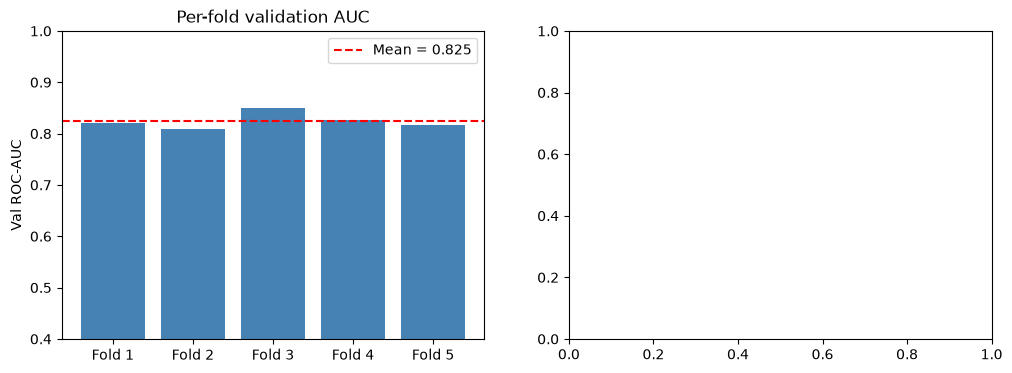

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([f"Fold {i+1}" for i in range(N_FOLDS)], fold_aucs, color="steelblue")
axes[0].axhline(fold_aucs.mean(), color="red", linestyle="--", label=f"Mean = {fold_aucs.mean():.3f}")
axes[0].set_ylabel("Val ROC-AUC"); axes[0].set_ylim(0.4, 1.0); axes[0].set_title("Per-fold validation AUC"); axes[0].legend()


In [24]:
for i, h in enumerate(fold_histories):
    axes[1].plot(h["val_auc"], label=f"Fold {i+1}")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val ROC-AUC")
axes[1].set_title("Val AUC per epoch (watch for the late-epoch decline seen before)")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

<Figure size 640x480 with 0 Axes>

Out-of-fold (5-fold CV) performance:

ROC-AUC (primary):  0.8218   (per-fold mean 0.8247 ± 0.0133)
Accuracy:            0.7473
Sensitivity (Disease recall): 0.7112
Specificity (Normal recall):  0.7939
F1:                   0.7605

              precision    recall  f1-score   support

      Normal       0.68      0.79      0.73      3052
     Disease       0.82      0.71      0.76      3948

    accuracy                           0.75      7000
   macro avg       0.75      0.75      0.75      7000
weighted avg       0.76      0.75      0.75      7000



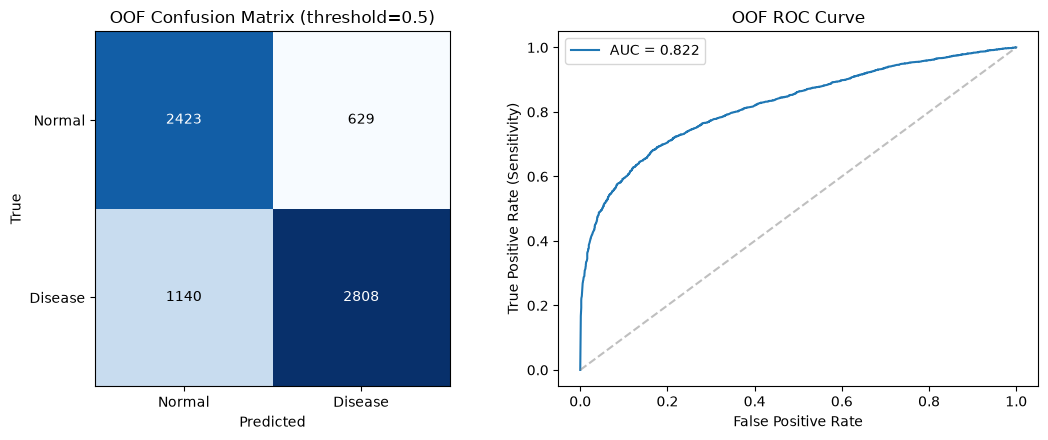


Youden-optimal threshold: 0.563
  Sensitivity: 0.6814
  Specificity: 0.8339


In [23]:
all_probs = oof_probs
all_labels = labeled_meta["label"].values


preds_05 = (all_probs >= 0.5).astype(int)

auc = roc_auc_score(all_labels, all_probs)
acc = accuracy_score(all_labels, preds_05)
sensitivity = recall_score(all_labels, preds_05, pos_label=1)   # recall on Disease
specificity = recall_score(all_labels, preds_05, pos_label=0)   # recall on Normal
f1 = f1_score(all_labels, preds_05)

print("Out-of-fold (5-fold CV) performance:\n")
print(f"ROC-AUC (primary):  {auc:.4f}   (per-fold mean {fold_aucs.mean():.4f} ± {fold_aucs.std():.4f})")
print(f"Accuracy:            {acc:.4f}")
print(f"Sensitivity (Disease recall): {sensitivity:.4f}")
print(f"Specificity (Normal recall):  {specificity:.4f}")
print(f"F1:                   {f1:.4f}")
print()
print(classification_report(all_labels, preds_05, target_names=["Normal", "Disease"]))

cm = confusion_matrix(all_labels, preds_05)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Normal", "Disease"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["Normal", "Disease"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True"); axes[0].set_title("OOF Confusion Matrix (threshold=0.5)")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.5)
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate (Sensitivity)")
axes[1].set_title("OOF ROC Curve"); axes[1].legend()

plt.tight_layout(); plt.show()

j_scores = tpr - fpr
best_thresh_idx = np.argmax(j_scores)
best_thresh = thresholds[best_thresh_idx]
preds_opt = (all_probs >= best_thresh).astype(int)
print(f"\nYouden-optimal threshold: {best_thresh:.3f}")
print(f"  Sensitivity: {recall_score(all_labels, preds_opt, pos_label=1):.4f}")
print(f"  Specificity: {recall_score(all_labels, preds_opt, pos_label=0):.4f}")


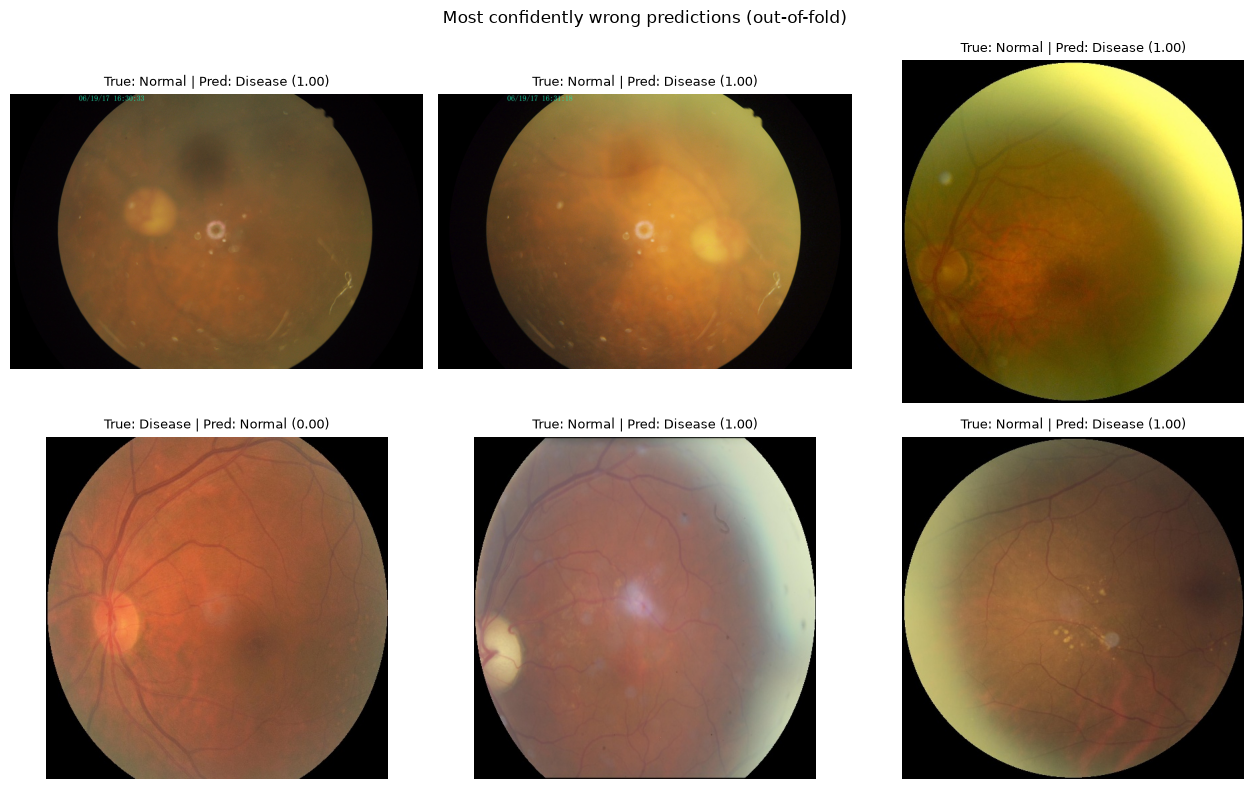

In [25]:
oof_scored = labeled_meta.copy()
oof_scored["prob_disease"] = all_probs
oof_scored["pred"] = preds_05
oof_scored["correct"] = oof_scored["pred"] == oof_scored["label"]
oof_scored["confidence_error"] = np.abs(oof_scored["prob_disease"] - oof_scored["label"])

worst = oof_scored[~oof_scored["correct"]].sort_values("confidence_error", ascending=False).head(6)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (_, row) in zip(axes.flat, worst.iterrows()):
    img = Image.open(row["path"]).convert("RGB")
    ax.imshow(img)
    true_lbl = "Disease" if row["label"] == 1 else "Normal"
    pred_lbl = "Disease" if row["pred"] == 1 else "Normal"
    ax.set_title(f"True: {true_lbl} | Pred: {pred_lbl} ({row['prob_disease']:.2f})", fontsize=9)
    ax.axis("off")
plt.suptitle("Most confidently wrong predictions (out-of-fold)")
plt.tight_layout(); plt.show()

Using fold 3 checkpoint for Grad-CAM (val AUC = 0.8489)


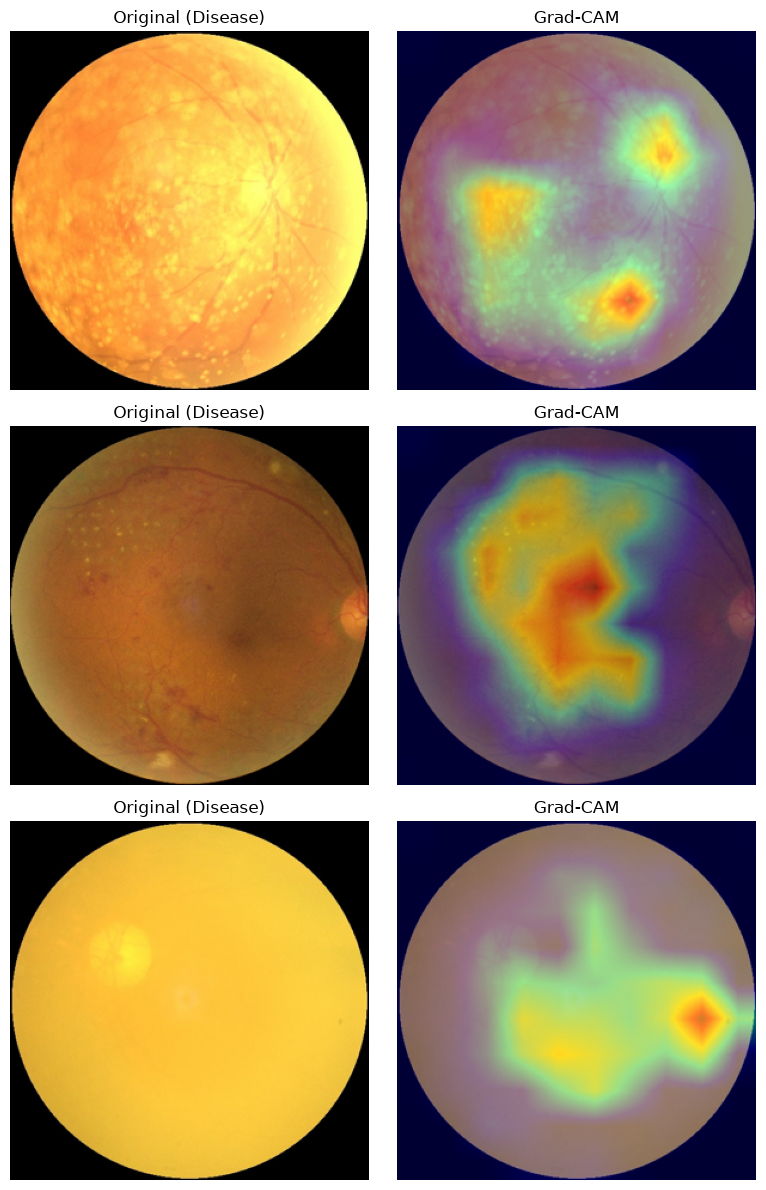

In [26]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.f_hook = target_layer.register_forward_hook(self._save_activation)
        self.b_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out.detach()

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def generate(self, x):
        self.model.zero_grad()
        logit = self.model(x)
        logit.backward()
        grads = self.gradients[0]
        acts = self.activations[0]
        weights = grads.mean(dim=(1, 2))
        cam = torch.relu((weights[:, None, None] * acts).sum(0))
        cam = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy()

    def remove(self):
        self.f_hook.remove()
        self.b_hook.remove()


def show_gradcam(model, dataset_row, transform, target_layer):
    img_pil = Image.open(dataset_row["path"]).convert("RGB")
    x = transform(img_pil).unsqueeze(0).to(device)
    x.requires_grad_(False)

    gradcam = GradCAM(model, target_layer)
    model.eval()
    cam = gradcam.generate(x)
    gradcam.remove()

    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    img_resized = np.array(img_pil.resize((IMG_SIZE, IMG_SIZE)))
    overlay = (0.6 * img_resized + 0.4 * heatmap).astype(np.uint8)
    return img_resized, overlay


# Load the best fold's checkpoint for explainability visuals
best_fold_idx = int(np.argmax(fold_aucs))
best_ckpt = torch.load(fold_checkpoint_paths[best_fold_idx], map_location=device)
gradcam_model = TransferClassifier(BACKBONE, pretrained=False).to(device)
gradcam_model.load_state_dict(best_ckpt["state_dict"])
gradcam_model.eval()
print(f"Using fold {best_fold_idx+1} checkpoint for Grad-CAM (val AUC = {fold_aucs[best_fold_idx]:.4f})")

sample_rows = oof_scored.sort_values("confidence_error").head(3)  # a few well-classified examples
fig, axes = plt.subplots(len(sample_rows), 2, figsize=(8, 4 * len(sample_rows)))
for row_i, (_, row) in enumerate(sample_rows.iterrows()):
    orig, overlay = show_gradcam(gradcam_model, row, eval_transform, gradcam_model.last_conv_layer)
    true_lbl = "Disease" if row["label"] == 1 else "Normal"
    axes[row_i, 0].imshow(orig); axes[row_i, 0].set_title(f"Original ({true_lbl})"); axes[row_i, 0].axis("off")
    axes[row_i, 1].imshow(overlay); axes[row_i, 1].set_title("Grad-CAM"); axes[row_i, 1].axis("off")
plt.tight_layout(); plt.show()


In [27]:
if len(unlabeled_meta) > 0:
    unlabeled_ds = ODIRImageDataset(
        unlabeled_meta.assign(label=0),  # placeholder; not used for prediction
        eval_transform
    )
    unlabeled_loader = DataLoader(unlabeled_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    all_test_fnames = None
    fold_test_probs = []  # one array of probs per fold

    for fold_idx, ckpt_path in enumerate(fold_checkpoint_paths):
        ckpt = torch.load(ckpt_path, map_location=device)
        fold_model = TransferClassifier(BACKBONE, pretrained=False).to(device)
        fold_model.load_state_dict(ckpt["state_dict"])
        fold_model.eval()

        test_probs, test_fnames = [], []
        with torch.no_grad():
            for imgs, _, fnames in tqdm(unlabeled_loader, desc=f"Fold {fold_idx+1} predicting on test set"):
                imgs = imgs.to(device)
                probs = torch.sigmoid(fold_model(imgs)).cpu().numpy()
                test_probs.extend(probs.tolist())
                test_fnames.extend(fnames)

        fold_test_probs.append(np.array(test_probs))
        if all_test_fnames is None:
            all_test_fnames = test_fnames
        else:
            assert test_fnames == all_test_fnames, "Fold prediction order mismatch — loader shuffled unexpectedly."

    ensemble_probs = np.mean(fold_test_probs, axis=0)  # simple average across the 5 folds

    submission = pd.DataFrame({
        "filename": all_test_fnames,
        "predicted_probability": ensemble_probs,
    })
    submission["predicted_label"] = (submission["predicted_probability"] >= 0.5).astype(int)
    submission.to_csv("submission_resnet_cv_gradunfreeze_odir.csv", index=False)
    print(f"Saved ensembled predictions for {len(submission)} images to submission.csv")
    submission.head()


Fold 1 predicting on test set:   0%|          | 0/8 [00:00<?, ?it/s]

Fold 2 predicting on test set:   0%|          | 0/8 [00:00<?, ?it/s]

Fold 3 predicting on test set:   0%|          | 0/8 [00:00<?, ?it/s]

Fold 4 predicting on test set:   0%|          | 0/8 [00:00<?, ?it/s]

Fold 5 predicting on test set:   0%|          | 0/8 [00:00<?, ?it/s]

Saved ensembled predictions for 1000 images to submission.csv


In [28]:
torch.save(model.state_dict(), "/home/compbio10/disc_novartis/resnet_cv_gradunfreeze_odir.pt")